# Telco Customer Churn: PyCaret vs. scikit-learn

**Asignatura:** Ciencia de Datos  
**Integrantes:** David Célleri, José Solórzano

## 1. Descarga del dataset

Dataset: **Telco Customer Churn (IBM Sample Data)**, publicado en Kaggle:
<https://www.kaggle.com/datasets/blastchar/telco-customer-churn>.

Se descarga con `kagglehub`. Si Kaggle no está disponible (sin conexión o sin credenciales),
se usa como respaldo la copia publicada por IBM en GitHub. El CSV se guarda en `data/`.

In [1]:
%pip install -q kagglehub

/home/david_c/Documentos/Documentos Universidad Borrables/CienciaDeDatos/TrabajoPipeline3/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import shutil
import urllib.request
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
CSV_PATH = DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

KAGGLE_DATASET = "blastchar/telco-customer-churn"
FALLBACK_URL = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
    "master/data/Telco-Customer-Churn.csv"
)

if CSV_PATH.exists():
    print(f"El dataset ya existe en {CSV_PATH}")
else:
    try:
        import kagglehub

        download_dir = Path(kagglehub.dataset_download(KAGGLE_DATASET))
        shutil.copy(next(download_dir.glob("*.csv")), CSV_PATH)
        print(f"Descargado desde Kaggle en {CSV_PATH}")
    except Exception as e:
        print(f"No se pudo descargar desde Kaggle ({e}); usando respaldo de IBM")
        urllib.request.urlretrieve(FALLBACK_URL, CSV_PATH)
        print(f"Descargado desde GitHub (IBM) en {CSV_PATH}")

print(f"Tamaño: {CSV_PATH.stat().st_size / 1024:.1f} KB")

El dataset ya existe en data/WA_Fn-UseC_-Telco-Customer-Churn.csv
Tamaño: 954.6 KB


## 2. Análisis inicial de los datos

Se revisa la estructura del dataset, los tipos de datos, la calidad (faltantes, duplicados,
valores inconsistentes) y la relación de las variables con el objetivo `Churn`.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)

# Paleta: azul = permanece (No), naranja = abandona (Yes)
COLOR_NO, COLOR_YES = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e4e3df",
    "axes.axisbelow": True,
})

df = pd.read_csv(CSV_PATH)
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 7,043 | Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 2.1 Tipos de datos y valores únicos

In [4]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "unicos": df.nunique(),
    "ejemplos": [df[c].unique()[:4].tolist() for c in df.columns],
})
resumen

,tipo,nulos,unicos,ejemplos
customerID,object,0,7043,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOCW]"
gender,object,0,2,"[Female, Male]"
SeniorCitizen,int64,0,2,"[0, 1]"
Partner,object,0,2,"[Yes, No]"
Dependents,object,0,2,"[No, Yes]"
tenure,int64,0,73,"[1, 34, 2, 45]"
PhoneService,object,0,2,"[No, Yes]"
MultipleLines,object,0,3,"[No phone service, No, Yes]"
InternetService,object,0,3,"[DSL, Fiber optic, No]"
OnlineSecurity,object,0,3,"[No, Yes, No internet service]"


`TotalCharges` debería ser numérica pero se leyó como texto, y `SeniorCitizen` es categórica
aunque está codificada como 0/1. Se revisa por qué `TotalCharges` no es numérica.

In [5]:
total_num = pd.to_numeric(df["TotalCharges"], errors="coerce")
no_numericos = df[total_num.isna()]
print(f"Valores no numéricos en TotalCharges: {len(no_numericos)}")
print(f"Valores distintos: {no_numericos['TotalCharges'].unique().tolist()}")
no_numericos[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Valores no numéricos en TotalCharges: 11
Valores distintos: [' ']


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Los 11 valores problemáticos son cadenas en blanco y corresponden a clientes con `tenure = 0`,
es decir, clientes recién incorporados a los que aún no se les ha facturado. No son datos
perdidos al azar: el cargo total real es 0.

### 2.2 Duplicados

In [6]:
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"customerID duplicados: {df['customerID'].duplicated().sum()}")
print(f"Filas duplicadas ignorando customerID: {df.drop(columns='customerID').duplicated().sum()}")

Filas duplicadas: 0
customerID duplicados: 0
Filas duplicadas ignorando customerID: 22


No hay registros repetidos. Las filas idénticas sin `customerID` son clientes distintos con el
mismo perfil (combinaciones comunes de servicios y cargos), por lo que se conservan.

### 2.3 Variable objetivo

In [7]:
churn = df["Churn"].value_counts()
print(pd.DataFrame({"clientes": churn, "porcentaje": (churn / len(df) * 100).round(1)}))

fig, ax = plt.subplots(figsize=(5, 2.2))
ax.barh(["Permanece (No)", "Abandona (Yes)"], [churn["No"], churn["Yes"]],
        color=[COLOR_NO, COLOR_YES], height=0.6)
for i, v in enumerate([churn["No"], churn["Yes"]]):
    ax.text(v + 60, i, f"{v:,} ({v / len(df):.1%})", va="center", fontsize=9)
ax.set_xlabel("Clientes")
ax.set_title("Distribución de Churn", loc="left")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, churn.max() * 1.25)
plt.tight_layout()
plt.show()

       clientes  porcentaje
Churn                      
No         5174        73.5
Yes        1869        26.5


<Figure size 550x242 with 1 Axes>

El dataset está **desbalanceado** (~73% / 27%). Por eso la propuesta mide AUC-ROC, F1 y recall de
la clase "abandona" en lugar de solo accuracy, y conviene usar particiones estratificadas.

### 2.4 Variables numéricas

In [8]:
df_num = df.assign(TotalCharges=total_num)
numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
df_num[numericas].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


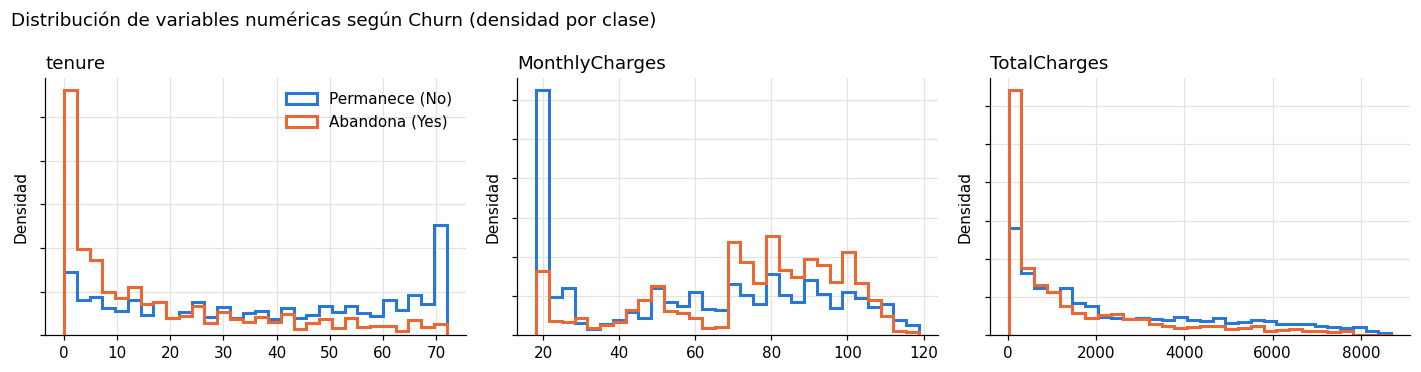

Medianas por clase:


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.43,1683.60
Yes,10.0,79.65,703.55


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col in zip(axes, numericas):
    datos = df_num[col].dropna()
    bins = 30
    rango = (datos.min(), datos.max())
    # Densidad para comparar la forma de ambas clases pese al desbalance
    for clase, color, etiqueta in [("No", COLOR_NO, "Permanece (No)"), ("Yes", COLOR_YES, "Abandona (Yes)")]:
        ax.hist(df_num.loc[df_num["Churn"] == clase, col].dropna(), bins=bins, range=rango,
                density=True, histtype="step", linewidth=2, color=color, label=etiqueta)
    ax.set_title(col, loc="left")
    ax.set_ylabel("Densidad")
    ax.set_yticklabels([])
axes[0].legend(frameon=False)
fig.suptitle("Distribución de variables numéricas según Churn (densidad por clase)", x=0.01, ha="left")
plt.tight_layout()
plt.show()

print("Medianas por clase:")
df_num.groupby("Churn")[numericas].median().round(2)

In [10]:
print("Correlación entre variables numéricas:")
df_num[numericas].corr().round(2)

Correlación entre variables numéricas:


,tenure,MonthlyCharges,TotalCharges
tenure,1.00,0.25,0.83
MonthlyCharges,0.25,1.00,0.65
TotalCharges,0.83,0.65,1.00


- Los clientes que abandonan tienen **antigüedad (`tenure`) mucho menor** y **cargos mensuales más altos**.
- `TotalCharges` está fuertemente correlacionada con `tenure` (≈ producto de antigüedad y cargo
  mensual), así que aporta información en gran parte redundante.
- No se observan valores atípicos imposibles (cargos negativos o antigüedades fuera de rango).

### 2.5 Variables categóricas: tasa de abandono por categoría

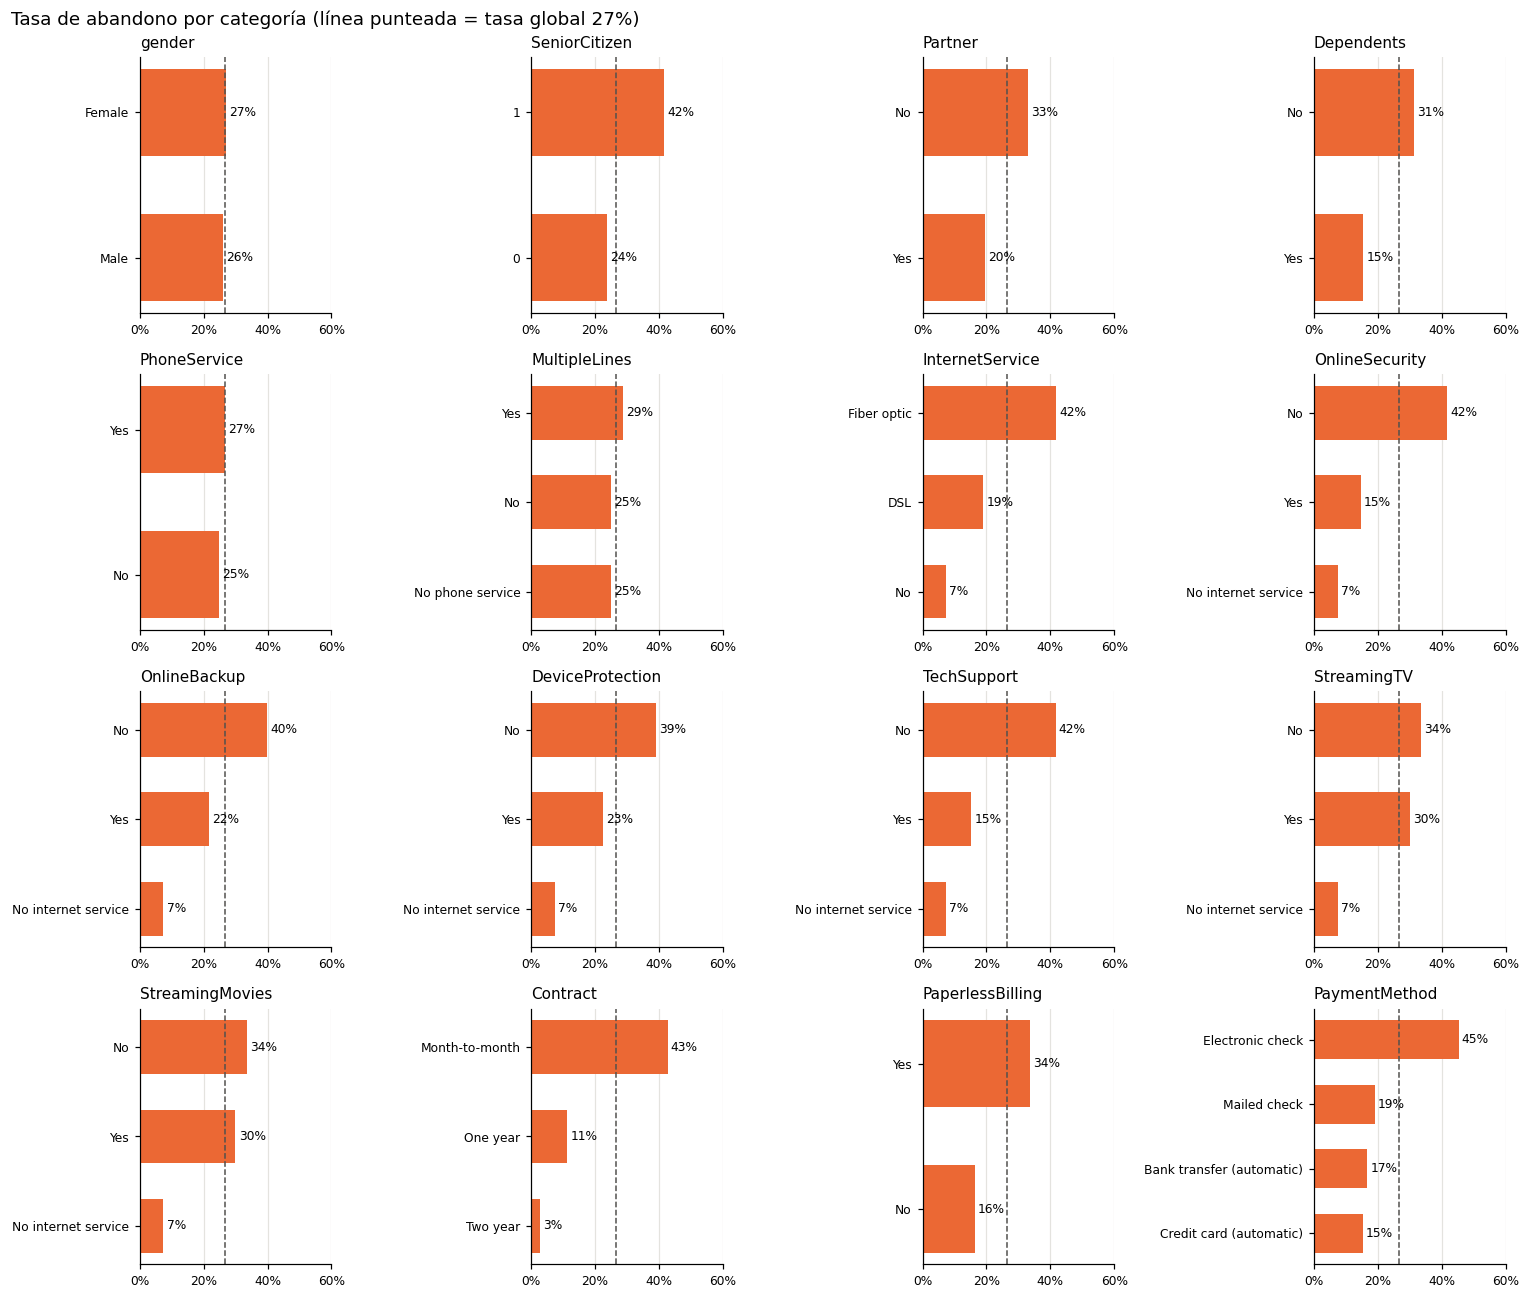

In [11]:
categoricas = [c for c in df.columns
               if c not in numericas + ["customerID", "Churn"]]

fig, axes = plt.subplots(4, 4, figsize=(14, 12))
tasa_global = (df["Churn"] == "Yes").mean()
for ax, col in zip(axes.flat, categoricas):
    tasa = df.groupby(col)["Churn"].apply(lambda s: (s == "Yes").mean()).sort_values()
    ax.barh(tasa.index.astype(str), tasa.values, color=COLOR_YES, height=0.6)
    ax.axvline(tasa_global, color="#52514e", linestyle="--", linewidth=1)
    for i, v in enumerate(tasa.values):
        ax.text(v + 0.01, i, f"{v:.0%}", va="center", fontsize=8)
    ax.set_title(col, loc="left", fontsize=10)
    ax.set_xlim(0, 0.6)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
    ax.tick_params(labelsize=8)
    ax.grid(axis="y", visible=False)
for ax in axes.flat[len(categoricas):]:
    ax.axis("off")
fig.suptitle(f"Tasa de abandono por categoría (línea punteada = tasa global {tasa_global:.0%})",
             x=0.01, ha="left")
plt.tight_layout()
plt.show()

Observaciones principales:

- **Contract**: los contratos mes a mes concentran el abandono; los de dos años casi no abandonan.
- **InternetService**: fibra óptica tiene una tasa de abandono claramente mayor que DSL.
- **PaymentMethod**: el cheque electrónico destaca frente a los pagos automáticos.
- Servicios de soporte (`OnlineSecurity`, `TechSupport`) se asocian con menor abandono.
- **SeniorCitizen**, sin pareja (`Partner`) o sin dependientes y con `PaperlessBilling` abandonan más.
- `gender` y `PhoneService` prácticamente no diferencian entre clases.
- La categoría "No internet service" / "No phone service" repite la información de
  `InternetService` / `PhoneService`; se mantiene porque es una categoría válida y el
  *one-hot encoding* la trata sin problema.

## 3. Limpieza de datos

Decisiones tomadas a partir del análisis:

1. **`TotalCharges`**: convertir a numérica; los 11 valores en blanco (clientes con `tenure = 0`)
   se reemplazan por **0**, que es su valor real, en lugar de eliminarlos o imputarlos con una estadística.
2. **`customerID`**: se elimina; es un identificador sin valor predictivo.
3. **`SeniorCitizen`**: se recodifica de 0/1 a "No"/"Yes" para tratarla como categórica, igual que el resto.
4. **`Churn`**: se codifica como 1 (abandona) / 0 (permanece) para que ambos enfoques usen la misma etiqueta positiva.
5. **Duplicados**: no se eliminan (son clientes distintos).

La imputación, codificación y escalado propios del modelado quedan para cada enfoque
(PyCaret y scikit-learn), de modo que ambos partan del mismo dataset limpio.

In [12]:
df_clean = df.copy()

df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"].str.strip(), errors="coerce")
df_clean.loc[df_clean["tenure"] == 0, "TotalCharges"] = (
    df_clean.loc[df_clean["tenure"] == 0, "TotalCharges"].fillna(0.0)
)

df_clean = df_clean.drop(columns="customerID")
df_clean["SeniorCitizen"] = df_clean["SeniorCitizen"].map({0: "No", 1: "Yes"})
df_clean["Churn"] = df_clean["Churn"].map({"No": 0, "Yes": 1}).astype(int)

df_clean.dtypes

gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

### 3.1 Verificación

In [13]:
assert df_clean.isna().sum().sum() == 0, "Quedan valores faltantes"
assert df_clean["TotalCharges"].dtype == "float64"
assert set(df_clean["Churn"].unique()) == {0, 1}
assert len(df_clean) == len(df)

print(f"Dimensiones: {df_clean.shape}")
print(f"Valores faltantes: {df_clean.isna().sum().sum()}")
print(f"Tasa de abandono: {df_clean['Churn'].mean():.2%}")
df_clean.describe(include="all").T

Dimensiones: (7043, 20)
Valores faltantes: 0
Tasa de abandono: 26.54%


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043,2,No,5901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,7043,3,No,3088,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Guardar el dataset limpio

In [14]:
CLEAN_PATH = DATA_DIR / "telco_churn_clean.csv"
df_clean.to_csv(CLEAN_PATH, index=False)
print(f"Dataset limpio guardado en {CLEAN_PATH} ({df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas)")

Dataset limpio guardado en data/telco_churn_clean.csv (7,043 filas × 20 columnas)


## 4. Configuración de PyCaret

PyCaret centraliza el preprocesamiento en `setup()`. La configuración se alinea con los
criterios de comparación de la propuesta, para que la regresión logística manual en
scikit-learn pueda replicar exactamente las mismas condiciones:

| Parámetro | Valor | Motivo |
|---|---|---|
| `target` | `Churn` (1 = abandona) | Clase positiva para recall y F1 |
| `train_size` | 0.8 | 80% entrenamiento / 20% prueba (*hold-out*) |
| `data_split_stratify` | `True` | Mantiene la proporción 73/27 en ambas particiones |
| `fold_strategy` / `fold` | `stratifiedkfold` / 5 | Validación cruzada de 5 folds estratificados (sin *shuffle*), como indica la propuesta |
| `session_id` | 42 | Semilla fija: partición y resultados reproducibles |
| `categorical_features` / `numeric_features` | explícitas | Evita que PyCaret infiera mal los tipos |
| `normalize` | `True` (*z-score*) | Escalado de todas las variables ya codificadas, necesario para modelos lineales |
| imputación | media / moda (por defecto) | El dataset limpio no tiene faltantes; queda como protección |
| codificación | automática | Binarias (6) → 0/1 ordinal; con 3-4 niveles (10) → *one-hot*. Resultado: 40 variables |

No se activan opciones adicionales (balanceo de clases, selección de variables, eliminación de
multicolinealidad) para que la comparación con la línea base manual sea justa.

> PyCaret 3.3 requiere **Python 3.11**. Ver `requirements.txt`.

In [15]:
import time

from pycaret.classification import ClassificationExperiment

df_model = pd.read_csv(CLEAN_PATH)

NUMERICAS = ["tenure", "MonthlyCharges", "TotalCharges"]
CATEGORICAS = [c for c in df_model.columns if c not in NUMERICAS + ["Churn"]]
SEMILLA = 42

exp = ClassificationExperiment()

inicio = time.perf_counter()
exp.setup(
    data=df_model,
    target="Churn",
    train_size=0.8,
    data_split_stratify=True,
    fold_strategy="stratifiedkfold",
    fold=5,
    numeric_features=NUMERICAS,
    categorical_features=CATEGORICAS,
    normalize=True,
    normalize_method="zscore",
    session_id=SEMILLA,
    verbose=True,
)
tiempo_setup = time.perf_counter() - inicio
print(f"Tiempo de setup: {tiempo_setup:.2f} s")

,Description,Value
0,Session id,42
1,Target,Churn
2,Target type,Binary
3,Original data shape,"(7043, 20)"
4,Transformed data shape,"(7043, 41)"
5,Transformed train set shape,"(5634, 41)"
6,Transformed test set shape,"(1409, 41)"
7,Numeric features,3
8,Categorical features,16
9,Preprocess,True


Tiempo de setup: 0.57 s


### 4.1 Verificación de la configuración

In [16]:
X_train, X_test = exp.get_config("X_train"), exp.get_config("X_test")
y_train, y_test = exp.get_config("y_train"), exp.get_config("y_test")

print(f"Entrenamiento: {X_train.shape[0]:,} filas | Prueba: {X_test.shape[0]:,} filas")
print(f"Tasa de abandono -> entrenamiento: {y_train.mean():.2%} | prueba: {y_test.mean():.2%}")
print(f"Variables tras el preprocesamiento: {exp.get_config('X_train_transformed').shape[1]}")
print(f"Validación cruzada: {exp.get_config('fold_generator')}")

Entrenamiento: 5,634 filas | Prueba: 1,409 filas
Tasa de abandono -> entrenamiento: 26.54% | prueba: 26.54%
Variables tras el preprocesamiento: 40
Validación cruzada: StratifiedKFold(n_splits=5, random_state=None, shuffle=False)


In [17]:
# Pasos del pipeline de preprocesamiento generado por PyCaret
exp.get_config("pipeline")

Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['tenure', 'MonthlyCharges',
                                             'TotalCharges'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='mean'))),
                ('categorical_imputer',
                 TransformerWrapper(exclude=None...
                                                                    'DeviceProtection',
                                                                    'TechSupport',
                                                                    'StreamingTV',
                                                                    'StreamingMovies',
                                                                    'Contract',
                                                                    'PaymentMethod'],
                                                              drop_invariant=False,
                                                              handle_missing='return_nan',
                                                              handle_unknown='value',
                                                              return_df=True,
                                                              use_cat_names=True,
                                                              verbose=0))),
                ('normalize',
                 TransformerWrapper(exclude=None, include=None,
                                    transformer=StandardScaler(copy=True,
                                                               with_mean=True,
                                                               with_std=True)))],
         verbose=False)

### 4.2 Guardar la partición

Se exportan los índices de entrenamiento y prueba para que la línea base en scikit-learn use
**exactamente la misma partición** (criterio 1 de la propuesta).

In [18]:
particion = pd.concat([
    pd.DataFrame({"indice": X_train.index, "conjunto": "train"}),
    pd.DataFrame({"indice": X_test.index, "conjunto": "test"}),
]).sort_values("indice")

SPLIT_PATH = DATA_DIR / "particion_train_test.csv"
particion.to_csv(SPLIT_PATH, index=False)
print(f"Partición guardada en {SPLIT_PATH}")
print(particion["conjunto"].value_counts())

Partición guardada en data/particion_train_test.csv
conjunto
train    5634
test     1409
Name: count, dtype: int64


## 5. Comparación de modelos con PyCaret

`compare_models()` entrena todos los clasificadores disponibles con la misma validación cruzada de
5 folds sobre el conjunto de entrenamiento y los ordena por la métrica elegida. Se ordena por
**AUC**, la métrica principal de la propuesta, porque no depende del umbral de decisión y es
robusta al desbalance de clases. Con `turbo=True` (valor por defecto) se omiten los modelos más
lentos (SVM con kernel RBF, proceso gaussiano y red neuronal MLP).

In [19]:
inicio = time.perf_counter()
top_modelos = exp.compare_models(sort="AUC", n_select=3)
tiempo_compare = time.perf_counter() - inicio

resultados_cv = exp.pull()
print(f"Tiempo de compare_models: {tiempo_compare:.1f} s")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8019,0.8468,0.5278,0.6584,0.5856,0.4576,0.4626,0.1420
lr,Logistic Regression,0.8040,0.8457,0.5485,0.6571,0.5977,0.4696,0.4731,0.2540
ada,Ada Boost Classifier,0.8042,0.8443,0.5358,0.6627,0.5921,0.4652,0.4701,0.0680
ridge,Ridge Classifier,0.8012,0.8384,0.5151,0.6618,0.5790,0.4515,0.4578,0.1960
lda,Linear Discriminant Analysis,0.8008,0.8384,0.5592,0.6442,0.5984,0.4669,0.4692,0.0360
lightgbm,Light Gradient Boosting Machine,0.7945,0.8331,0.5191,0.6388,0.5722,0.4390,0.4434,0.3300
nb,Naive Bayes,0.6935,0.8217,0.8482,0.4588,0.5953,0.3824,0.4293,0.2000
rf,Random Forest Classifier,0.7843,0.8201,0.4856,0.6193,0.5442,0.4057,0.4110,0.2380
svm,SVM - Linear Kernel,0.7696,0.8088,0.5264,0.5717,0.5383,0.3878,0.3945,0.2080
et,Extra Trees Classifier,0.7742,0.7928,0.4923,0.5894,0.5365,0.3888,0.3916,0.0760


Tiempo de compare_models: 13.6 s


In [20]:
# Métricas de la propuesta: AUC, F1 y recall de la clase "abandona"
resultados_cv[["Model", "AUC", "Recall", "F1", "Accuracy", "TT (Sec)"]]

,Model,AUC,Recall,F1,Accuracy,TT (Sec)
gbc,Gradient Boosting Classifier,0.8468,0.5278,0.5856,0.8019,0.142
lr,Logistic Regression,0.8457,0.5485,0.5977,0.8040,0.254
ada,Ada Boost Classifier,0.8443,0.5358,0.5921,0.8042,0.068
ridge,Ridge Classifier,0.8384,0.5151,0.5790,0.8012,0.196
lda,Linear Discriminant Analysis,0.8384,0.5592,0.5984,0.8008,0.036
lightgbm,Light Gradient Boosting Machine,0.8331,0.5191,0.5722,0.7945,0.330
nb,Naive Bayes,0.8217,0.8482,0.5953,0.6935,0.200
rf,Random Forest Classifier,0.8201,0.4856,0.5442,0.7843,0.238
svm,SVM - Linear Kernel,0.8088,0.5264,0.5383,0.7696,0.208
et,Extra Trees Classifier,0.7928,0.4923,0.5365,0.7742,0.076


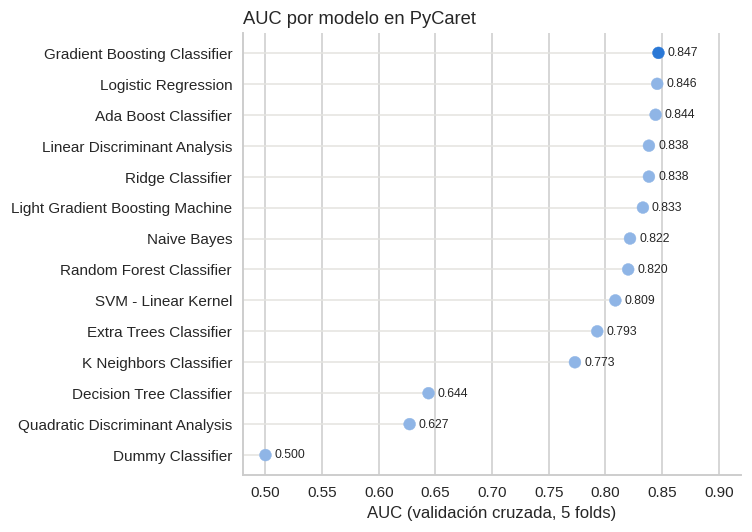

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
orden = resultados_cv.sort_values("AUC")
mejor = orden.index[-1]
ax.hlines(orden["Model"], orden["AUC"].min() - 0.02, orden["AUC"], color="#e4e3df", linewidth=1)
ax.scatter(orden["AUC"], orden["Model"], s=60, zorder=3,
           color=["#2a78d6" if i == mejor else "#8fb5e6" for i in orden.index])
for modelo, v in zip(orden["Model"], orden["AUC"]):
    ax.text(v + 0.008, modelo, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(orden["AUC"].min() - 0.02, 0.92)
ax.set_xlabel("AUC (validación cruzada, 5 folds)")
ax.set_title("AUC por modelo en PyCaret", loc="left")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### 5.1 Evaluación de los mejores modelos en el conjunto de prueba

Las métricas de validación cruzada se calculan solo con el entrenamiento. Para confirmar que los
mejores modelos generalizan, se evalúan los 3 primeros sobre el 20% de prueba, que no se usó en
ningún momento de la comparación.

In [22]:
filas = []
for modelo in top_modelos:
    exp.predict_model(modelo, verbose=False)
    metricas = exp.pull().iloc[0]
    filas.append(metricas[["Model", "AUC", "Recall", "F1", "Accuracy"]])

resultados_test = pd.DataFrame(filas).reset_index(drop=True)
resultados_test

,Model,AUC,Recall,F1,Accuracy
0,Gradient Boosting Classifier,0.8434,0.5160,0.5813,0.8027
1,Logistic Regression,0.8418,0.5668,0.6092,0.8070
2,Ada Boost Classifier,0.8397,0.5267,0.5820,0.7991


In [23]:
mejor_modelo = top_modelos[0]
print(f"Mejor modelo según AUC en validación cruzada: {resultados_cv.iloc[0]['Model']}")
mejor_modelo

Mejor modelo según AUC en validación cruzada: Gradient Boosting Classifier


GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=42, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

### 5.2 Diagnóstico del mejor modelo

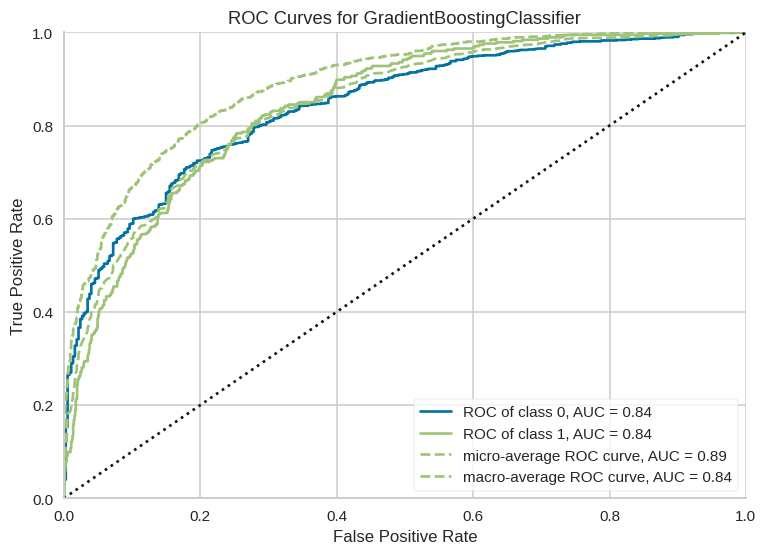

In [24]:
exp.plot_model(mejor_modelo, plot="auc")

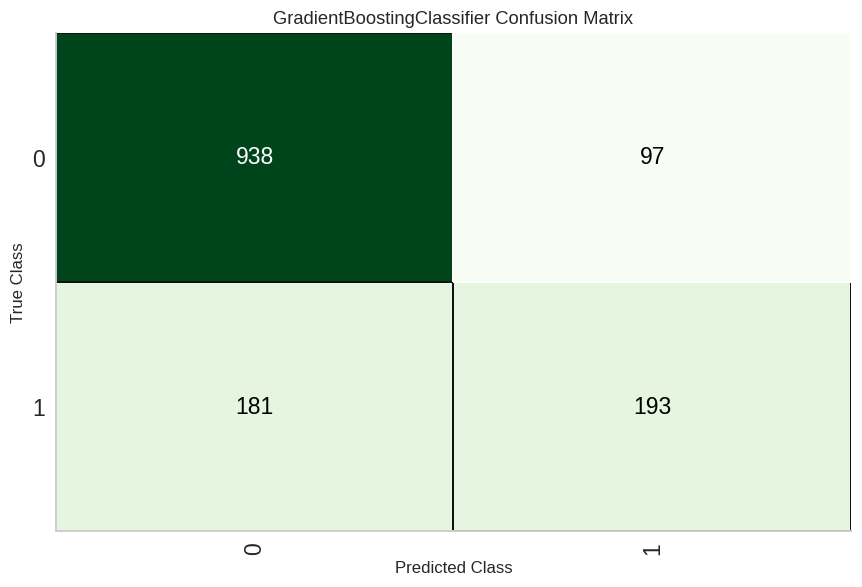

In [25]:
exp.plot_model(mejor_modelo, plot="confusion_matrix")

### 5.3 Resultados

- **Mejor modelo: Gradient Boosting Classifier**, con AUC de 0,847 en validación cruzada y 0,843 en
  el conjunto de prueba. Las métricas casi no bajan en prueba, así que no hay señales de sobreajuste.
- La diferencia con los siguientes es mínima: **la regresión logística queda segunda (0,846)** y
  AdaBoost tercero (0,844). Diferencias de ~0,001 en AUC están dentro de la variación normal entre
  folds, así que en la práctica los tres modelos están empatados.
- En prueba, la regresión logística incluso obtiene mejor recall (0,567 vs. 0,516) y F1
  (0,609 vs. 0,581) que Gradient Boosting.
- El recall de todos los modelos ronda 0,5: con el umbral por defecto de 0,5 se detecta solo
  alrededor de la mitad de los clientes que abandonan (193 de 374 en prueba). La excepción es
  Naive Bayes, con recall de 0,85 pero a costa de muchos falsos positivos (accuracy de 0,69).
- `compare_models()` evaluó 14 modelos con 5 folds en unos 14 segundos, con una sola línea de código.

Para la pregunta del proyecto esto es relevante: PyCaret encuentra un modelo ligeramente mejor
en AUC, pero la regresión logística, que será la línea base en scikit-learn, rinde prácticamente igual.